<a href="https://colab.research.google.com/github/jayaprakashdigajarla-ops/Machine-Learning-File/blob/main/Linear_Regression2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression

In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

In [3]:
#UPLOAD DATASET
df = pd.read_csv('/content/car_dataset.data',names=headers)

In [4]:
#LOAD DATASET
print("Original Data:")
print(df.head())

Original Data:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compre

In [5]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns

print("\nBasic Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values Count:")
print(df.isnull().sum())


Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size  

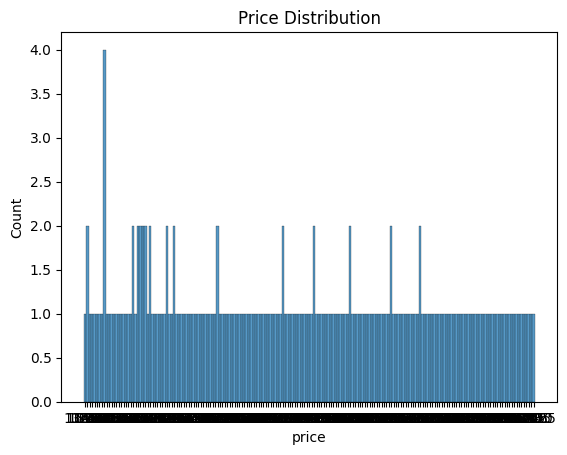

In [6]:
# Price Distribution
plt.figure()
sns.histplot(df["price"], bins=30)
plt.title("Price Distribution")
plt.show()

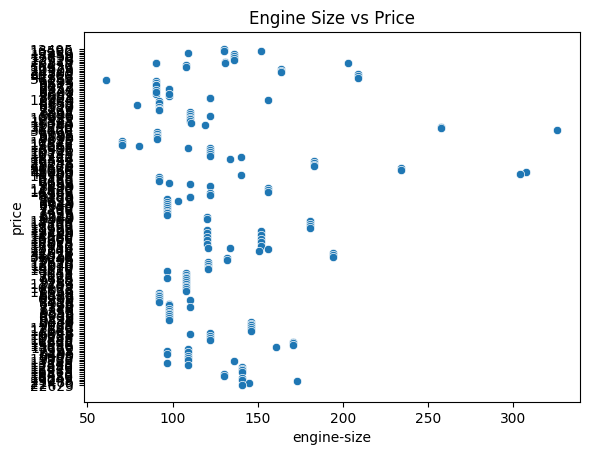

In [7]:
# Scatter Plot
plt.figure()
sns.scatterplot(x=df["engine-size"], y=df["price"])
plt.title("Engine Size vs Price")
plt.show()

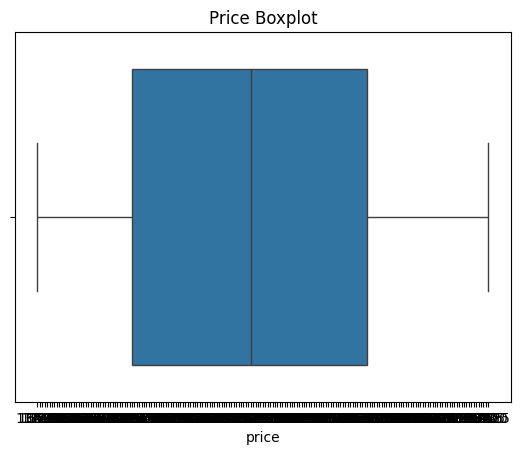

In [8]:
plt.figure()
sns.boxplot(x=df["price"])
plt.title("Price Boxplot")
plt.show()

In [9]:
# 5. DATA PREPROCESSING
df.replace("?", np.nan, inplace=True)

In [10]:
# Convert numeric columns
num_cols = ["normalized-losses","bore","stroke","horsepower","peak-rpm","price"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
# Fill missing numeric values
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)


/tmp/ipykernel_9254/3193654592.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [12]:
# Fill categorical missing values
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_9254/2309876184.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [13]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
# Drop rows where price is missing
df.dropna(subset=["price"], inplace=True)
print("\nCleaned Data:")
print(df.head())


Cleaned Data:
   symboling  normalized-losses  make  fuel-type  aspiration  num-of-doors  \
0          3              122.0     0          1           0             1   
1          3              122.0     0          1           0             1   
2          1              122.0     0          1           0             1   
3          2              164.0     1          1           0             0   
4          2              164.0     1          1           0             0   

   body-style  drive-wheels  engine-location  wheel-base  ...  engine-size  \
0           0             2                0        88.6  ...          130   
1           0             2                0        88.6  ...          130   
2           2             2                0        94.5  ...          152   
3           3             1                0        99.8  ...          109   
4           3             0                0        99.4  ...          136   

   fuel-system  bore  stroke  compression-ratio

In [15]:
# 6. FEATURE SCALING
X = df.drop("price", axis=1)
y = df["price"]

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("price", axis=1)
y = df["price"]

X_scaled = scaler.fit_transform(X)

In [17]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [18]:
#MODEL TRAINING
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [19]:
#PREDICTION
y_pred = model.predict(X_test)

In [20]:
print("\n Linear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))



 Linear Regression Results:
MSE: 12177436.277669035
R2 Score: 0.8185501326703339


In [21]:
print("\nModel Coefficients:")
print(model.coef_)


Model Coefficients:
[ 3.80804036e+01 -2.40736181e+01 -2.41892162e+02  6.46914502e+03
  3.61060679e+03 -1.38774579e+02 -8.36658861e+02  1.17807856e+03
  1.26066525e+04  2.70833577e+01  3.82644677e+01  8.70269775e+02
  1.62650424e+02  1.30375153e+00  1.29449929e+02  1.58697610e+03
  1.76205895e+02  3.59919492e+02 -1.36642886e+03 -4.03336679e+03
  4.35272131e+02 -7.82182844e+01  3.08875943e+00 -4.25110082e+01
  1.15621281e+02]


In [22]:
new_car = [[
    3,      # symboling
    120,    # normalized_losses
    0,      # make (encoded value)
    1,      # fuel_type
    0,      # aspiration
    1,      # num_doors
    2,      # body_style
    1,      # drive_wheels
    0,      # engine_location
    100,    # wheel_base
    170,    # length
    65,     # width
    54,     # height
    2500,   # curb_weight
    2,      # engine_type
    3,      # num_cylinders
    130,    # engine_size
    1,      # fuel_system
    3.5,    # bore
    2.8,    # stroke
    9.0,    # compression_ratio
    110,    # horsepower
    5000,   # peak_rpm
    25,     # city_mpg
    30      # highway_mpg
]]

In [23]:
new_car = pd.DataFrame(new_car, columns=X.columns)

print("\nInput Data:")
print(new_car)


Input Data:
   symboling  normalized-losses  make  fuel-type  aspiration  num-of-doors  \
0          3                120     0          1           0             1   

   body-style  drive-wheels  engine-location  wheel-base  ...  \
0           2             1                0         100  ...   

   num-of-cylinders  engine-size  fuel-system  bore  stroke  \
0                 3          130            1   3.5     2.8   

   compression-ratio  horsepower  peak-rpm  city-mpg  highway-mpg  
0                9.0         110      5000        25           30  

[1 rows x 25 columns]


In [26]:
predicted_price = model.predict(new_car)

print("\n Predicted Car Price:", predicted_price[0])


 Predicted Car Price: 16352.391462237618
